# mbo_utilities: User Guide

[**Installation**](https://millerbrainobservatory.github.io/mbo_utilities/index.html#quick-start) |
[**Supported Formats**](https://millerbrainobservatory.github.io/mbo_utilities/file_formats.html) |
[**MBO Hub**](https://millerbrainobservatory.github.io/)

An image I/O library with an intuitive GUI for scientific imaging data.

## Reading and Writing Data

`imread` is a lazy-file reader.

Pass a file, list of files, or directory and it will read the image data and metadata.

Wrap a numpy array with imread(array) and have access to all lazy operations.

Volumetric data are read by passing in the directory containing each z-plane.

```python
# Read any supported format - returns a lazy array
arr = mbo.imread(
    inputs,                      # Path, list of paths, directory, or numpy array
    # ScanImage TIFF options ---
    roi=None,                    # ROI selection: None=stitch, 0=split, N=specific ROI
    fix_phase=True,              # Enable bidirectional scan-phase correction
    phasecorr_method="mean",     # Phase estimation: "mean", "median", or "max"
    use_fft=False,               # Use FFT-based subpixel correction (slower, more precise)
    upsample=5,                  # Upsampling factor for subpixel phase estimation
    border=3,                    # Border pixels to exclude from phase calculation
    max_offset=4,                # Maximum phase offset to search (pixels)
    **kwargs                     # Additional format-specific options
)

# Write to any supported format
mbo.imwrite(
    lazy_array,                  # Source array (from imread or np.ndarray wrapped)
    outpath,                     # Output directory or file path
    ext=".tiff",                 # Output format: ".tiff", ".zarr", ".h5", ".bin", ".npy"
    planes=None,                 # Z-planes to export (1-based): None=all, int, or list
    frames=None,                 # Timepoints to export (1-based): None=all, int, or list
    channels=None,               # Channels to export (1-based): None=all, int, or list
    num_frames=None,             # Number of frames to write (None=all)
    roi_mode="concat_y",         # ROI handling: "concat_y" (stitch) or "separate"
    roi=None,                    # Specific ROI(s) when roi_mode="separate"
    register_z=False,            # Compute + apply axial plane-to-plane shifts
    metadata=None,               # Additional metadata dict to embed
    overwrite=False,             # Overwrite existing files
    order=None,                  # Reorder planes before writing
    target_chunk_mb=100,         # Target chunk size in MB for streaming
    output_name=None,            # Custom filename for .bin output
    output_suffix=None,          # Custom filename suffix (default: none)
    dataset_name=None,           # Dataset name for .h5 output
    dim_order=None,              # Axis labels for in-memory numpy arrays (e.g. "TZYX")
    progress_callback=None,      # Callback: func(progress, current_plane)
    show_progress=True,          # Show tqdm progress bar
    debug=False,                 # Enable verbose logging
    # Zarr-specific options (ext=".zarr") ---
    sharded=True,                # Use sharding (recommended for large data)
    ome=True,                    # Write OME-NGFF metadata
    compressor="none",           # "none", "gzip", "zstd", "blosc-lz4", "blosc-zstd"
    compression_level=1,         # compressor-specific level (gzip 0-9, zstd 1-22, blosc 1-9)
    pyramid=False,               # Generate multi-resolution pyramid
    pyramid_max_layers=4,        # Max pyramid resolution levels
    pyramid_method="mean",       # Pyramid downsampling method
    **kwargs                     # Additional format-specific options
)
```

In [1]:
from pathlib import Path
import numpy as np
import mbo_utilities as mbo
import matplotlib.pyplot as plt

RAW_PATH = Path(r"D:/demo/raw")
SAVE_PATH = RAW_PATH.parent / "corrected"

### Load a data file

This demo will use raw ScanImage tiffs.

Raw ScanImage TIFFs are detected automatically and return an `MboRawArray`:

In [ ]:
help(mbo.imread)

In [2]:
arr = mbo.imread(RAW_PATH)

print(f"Type: {type(arr).__name__}")
print(f"Shape (T, C, Z, Y, X): {arr.shape}")
print(f"Planes: {arr.num_planes}, Frames: {arr.num_frames}, ScanImage multi-ROIs: {arr.num_rois}")

Counting frames:   0%|          | 0/2 [00:00<?, ?it/s]

Type: LBMArray
Shape (T, C, Z, Y, X): (1574, 1, 14, 550, 448)
Planes: 14, Frames: 1574, ScanImage multi-ROIs: 2


### Save a small test dataset

Extract 100 frames from planes 7-9 to work with.

By default the filename is built from dimension tags only; pass `output_suffix` to append a custom suffix:

In [3]:
# arr.fix_phase = True  # Enable scan-phase correction
# arr.roi = None        # Stitch ROIs together

saved = mbo.imwrite(
    arr,
    SAVE_PATH,
    ext=".zarr",
    planes=[7, 8, 9],
    # num_frames=100,
    overwrite=True,
    roi=None,                    # 0 to separate, None to stitch ROIs
    output_suffix="example",     # filename suffix -> ..._zplane07-09_example.zarr
)
print(f"Saved to: {saved}")

Writing Zarr:   0%|          | 0/1574 [00:00<?, ?frames/s]

Saved to: D:\demo\corrected


### Read and explore the saved data

In [5]:
# read the saved volume
arr = mbo.imread(saved)
print(f"Shape (T, C, Z, Y, X): {arr.shape}, Dtype: {arr.dtype}")

Shape (T, C, Z, Y, X): (1574, 1, 3, 550, 448), Dtype: int16


In [6]:
# Numpy-like indexing
frame = arr[0, 0, 0]        # First frame (Y, X)
subset = arr[10:20]         # Frames 10-19
crop = arr[:100, 0, 0, 100:200, 100:200]  # Spatial crop (T, Y, X)

print(f"Single frame: {frame.shape}")
print(f"Subset: {subset.shape}")
print(f"Crop: {crop.shape}")

Single frame: (550, 448)
Subset: (10, 1, 3, 550, 448)
Crop: (100, 100, 100)


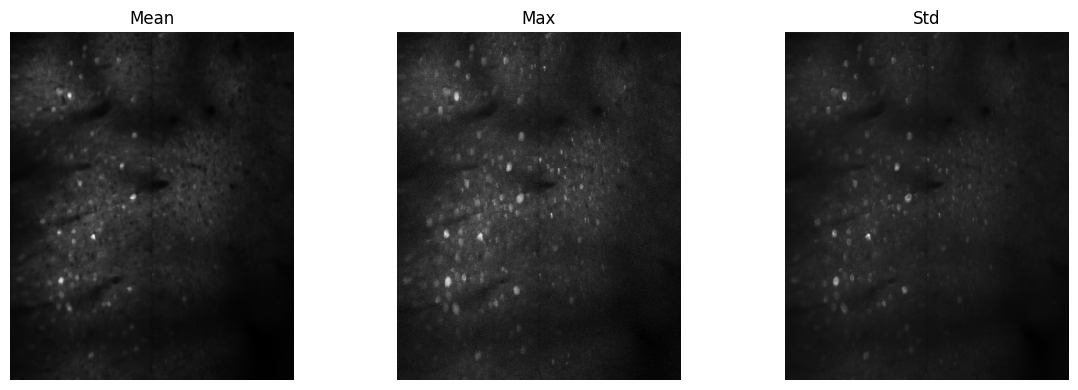

In [8]:
# Reduction operations
mean_img = arr[:200, 0, 0].mean(axis=0)
max_img = arr[:200, 0, 0].max(axis=0)
std_img = arr[:200, 0, 0].std(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(mean_img, cmap='gray'); axes[0].set_title('Mean')
axes[1].imshow(max_img, cmap='gray'); axes[1].set_title('Max')
axes[2].imshow(std_img, cmap='gray'); axes[2].set_title('Std')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

## Accessing metadata

All lazy arrays expose metadata via the `.metadata` property:

```python
metadata = arr.metadata
```

### Imaging vs Acquisition Metadata

**Imaging metadata** describes the physical data:
- `dx`, `dy`, `dz` - voxel size in µm
- `fs` - frame rate in Hz
- `Lx`, `Ly` - image dimensions in pixels
- `num_zplanes`, `num_timepoints`, `dtype`

**Acquisition metadata** describes how the data was collected (ScanImage-specific):
- `num_mrois` - number of scan regions
- `roi_groups`, `roi_heights` - ROI configuration
- `fix_phase`, `phasecorr_method` - scan-phase correction settings
- `zoom_factor`, `objective_resolution` - optical parameters

### Array-Type-Specific Metadata

Some metadata only applies to certain stack types:

| Parameter | LBM Stack | Piezo Stack | Single Plane |
|-----------|:---------:|:-----------:|:------------:|
| `num_zplanes` | > 1 | > 1 | 1 |
| `dz` | user-supplied | from SI | N/A |
| `frame_averaging` | no | yes | yes |
| `bidirectional_scan` | yes | varies | varies |

### Quick Access

View metadata via CLI:
```bash
uv run mbo info /path/to/data
uv run mbo /path/to/data --metadata
```

In [9]:
from pprint import pprint
pprint(arr.metadata, depth=1)

{'C': 14,
 'ImageLength': 1116,
 'ImageWidth': 224,
 'LX': 224,
 'LY': 1116,
 'Lx': 448,
 'Ly': 550,
 'PhysicalSizeX': 2.0,
 'PhysicalSizeXUnit': 'micrometer',
 'PhysicalSizeY': 2.0,
 'PhysicalSizeYUnit': 'micrometer',
 'PhysicalSizeZ': None,
 'PhysicalSizeZUnit': 'micrometer',
 'T': 1574,
 'Z': 3,
 'apply_shift': False,
 'border': 3,
 'channels': 14,
 'color_channels': 1,
 'data_type': 'int16',
 'datatype': 'int16',
 'dims': [...],
 'dtype': dtype('<i2'),
 'dx': 2.0,
 'dy': 2.0,
 'dz': None,
 'file_paths': [...],
 'finterval': 0.07142857142857142,
 'fix_phase': True,
 'fov': [...],
 'fov_px': [...],
 'fov_um': [...],
 'fov_x': 224,
 'fov_y': 1116,
 'fps': 14.0,
 'fr': 14.0,
 'frameRate': 14.0,
 'frame_rate': 14.0,
 'frames_per_file': [...],
 'fs': 14.0,
 'height': 1116,
 'image_height': 1116,
 'image_width': 224,
 'is_contiguous': True,
 'is_lbm': True,
 'is_piezo': False,
 'lbmStack': True,
 'lbm_stack': True,
 'lx': 224,
 'ly': 1116,
 'max_offset': 4,
 'mean_subtraction': False,
 'n

## Saving data: Formats and Conversions

Convert between any supported formats with `imwrite()`.

Here, we load the .zarr previously saved, add some metadata, and re-save to several of the supported formats.

Note: Keep different filetypes in separate directories.

```{warning}
When saving z-planes with inconsistent frame counts (e.g., some planes have 1574 frames, others have 1500), only the minimum number of frames across all planes will be written.
```

In [ ]:
new_metadata = {"test": [123]}

# Each format takes its own array-specific options alongside `metadata`:
# zarr: storage layout (sharding + compression)
mbo.imwrite(arr, SAVE_PATH / "zarr", ext=".zarr", overwrite=True,
            metadata=new_metadata, sharded=True, compressor="zstd")
# tiff: no format-specific options
mbo.imwrite(arr, SAVE_PATH / "tiff", ext=".tiff", overwrite=True,
            metadata=new_metadata)
# h5: dataset name to write the volume under
mbo.imwrite(arr, SAVE_PATH / "hdf5", ext=".h5", overwrite=True,
            metadata=new_metadata, dataset_name="mov")
# suite2p .bin: needs the frame rate (fs) for ops.npy
mbo.imwrite(arr, SAVE_PATH / "suite2p", ext=".bin", overwrite=True,
            metadata={**new_metadata, "fs": 17.0})

print(f"New metadata: {mbo.imread(SAVE_PATH / 'tiff').metadata['test']}")

### Working with In-Memory Numpy Arrays

You can wrap any numpy array with `imread()` to get full `imwrite()` support, including zarr chunking, compression, and sharding.

For detailed documentation on `NumpyArray` properties, methods, and use cases, see [Supported Formats](https://millerbrainobservatory.github.io/mbo_utilities/file_formats.html#numpyarray).

In [ ]:
import numpy as np
import mbo_utilities as mbo

data = np.random.randn(100, 512, 512).astype(np.float32)
np_out = RAW_PATH.parent / "test_numpy_array"

# Wrap with imread - returns a NumpyArray lazy array
arr = mbo.imread(data)
print(arr)  # NumpyArray(shape=(100, 1, 1, 512, 512), dtype=float32, dims='TCZYX' (in-memory))

# Now you can use imwrite with all features
mbo.imwrite(arr, np_out, ext=".zarr")   # Zarr with chunking/sharding
mbo.imwrite(arr, np_out, ext=".tiff")   # BigTIFF
mbo.imwrite(arr, np_out, ext=".bin", metadata={"fs": 14})    # Suite2p binary format
mbo.imwrite(arr, np_out, ext=".h5")     # HDF5

# 4D arrays (T, Z, Y, X) also work
volume = np.random.randn(100, 15, 512, 512).astype(np.float32)
arr4d = mbo.imread(volume)
print(f"dims: {arr4d.dims}, num_planes: {arr4d.num_planes}")  # dims: TCZYX, num_planes: 15

# Write specific planes (1-based indexing)
mbo.imwrite(arr4d, np_out, ext=".zarr", planes=[1, 8, 15])

## User Interface: MBO-GUI

The GUI can be launched in two ways:

**From Python** (Jupyter Lab or Jupyter Notebook only, not VSCode):
```python
from mbo_utilities.gui import run_gui
run_gui(arr)
```

**From the command line** (works anywhere):
```bash
uv run mbo /path/to/data
```

See the [GUI documentation](https://millerbrainobservatory.github.io/mbo_utilities/usage/gui_guide.html) for details.

In [27]:
# To run from the command line, through jupyter:
!uv run mbo --help

Usage: mbo [OPTIONS] COMMAND [ARGS]...

  MBO Utilities CLI - data preview and processing tools.

  GUI Mode:
    mbo                            Open file selection dialog
    mbo /path/to/data              Open specific file in GUI
    mbo /path/to/data --metadata   Show only metadata

  Commands:
    mbo init [DATA_PATH]           Create starter notebooks
    mbo convert INPUT OUTPUT       Convert between formats
    mbo info INPUT                 Show array information (CLI)
    mbo formats                    List supported formats

  Utilities:
    mbo --check-install                 Verify installation

Options:
  --check-install       Verify the installation of mbo_utilities and
                        dependencies.
  --help                Show this message and exit.

Commands:
  convert  Convert imaging data between formats.
  formats  List supported file formats.
  info     Show information about an imaging dataset.
  init     Create starter notebooks (mbo + LBM-Suite2p user gu

In [24]:
!uv run mbo info D:/demo/raw

Loading: D:/demo/raw

Array Information:
  Type:  MboRawArray
  Shape: (1574, 14, 550, 448)
  Dtype: int16
  Ndim:  4
  Files: 2
    - D:\demo\raw\demo_mk355_7_27_2025_00001.tif
    - D:\demo\raw\demo_mk355_7_27_2025_00002.tif

Metadata:
  nframes: 1574
  num_frames: 1574
  num_rois: 2
  ... and 42 more keys



Counting frames: 100%|██████████| 2/2 [00:00<?, ?it/s]


## Special array characteristics

Lazy arrays have special characteristics depending on what the filetype is used for.

### Bi-directional Scan-phase correction (ScanImage Tiff)

ScanImage Tiffs (MboRawArray) only.

Bidirectional scanning creates phase offsets between alternating lines:

![Scan phase correction](https://raw.githubusercontent.com/MillerBrainObservatory/mbo_utilities/master/docs/_images/corr_nocorr_phase_example.png)

In [ ]:
arr = mbo.imread(RAW_PATH)
arr.roi = None
z = 13  # plane with the largest residual scan-phase offset in this dataset

# scan-phase correction OFF: raw frames as acquired
arr.fix_phase = False
raw = arr[:, 0, z].mean(axis=0)

# scan-phase correction ON, subpixel (FFT) so a sub-pixel shift is actually applied
# (use_fft=False rounds to whole pixels, so offsets < 0.5 px become a no-op)
arr.fix_phase = True
arr.use_fft = True
cor = arr[:, 0, z].mean(axis=0)
print(f"detected scan-phase offset: {arr.offset:.2f} px (subpixel)")

# zoom to a central window so the per-row shift is easier to see
h, w = raw.shape
crop = (slice(h // 2 - 60, h // 2 + 60), slice(w // 2 - 90, w // 2 + 90))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(raw[crop], cmap="gray")
axes[0].set_title("No correction (raw)", fontsize=12, fontweight="bold")
axes[1].imshow(cor[crop], cmap="gray")
axes[1].set_title(f"Corrected ({arr.offset:.2f} px, subpixel)", fontsize=12, fontweight="bold")
axes[2].imshow((cor - raw)[crop], cmap="bwr")
axes[2].set_title("Difference (corrected - raw)", fontsize=12, fontweight="bold")
for a in axes:
    a.axis("off")
plt.tight_layout()
plt.show()

### Multi-ROI handling (ScanImage Tiff)

Control how multiple ROIs are handled.

By default, they are stitched horizontally:

![ROI assembly](https://raw.githubusercontent.com/MillerBrainObservatory/mbo_utilities/master/docs/_images/assembly_1.png)

In [25]:
arr = mbo.imread(RAW_PATH)
print(f"ROIs: {arr.num_rois}")

# roi=None: Stitch horizontally (default)
arr.roi = None
print(f"Stitched shape: {arr[0, 0, 7].shape}")

# roi=N: select a specific ROI (1-indexed)
arr.roi = 1
print(f"ROI 1 shape: {arr[0, 0, 7].shape}")
arr.roi = 2
print(f"ROI 2 shape: {arr[0, 0, 7].shape}")

Counting frames:   0%|          | 0/2 [00:00<?, ?it/s]

ROIs: 2
Stitched shape: (550, 448)
ROI 1 shape: (550, 224)
ROI 2 shape: (550, 224)


### Axial registration (plane-to-plane phase correlation)

Light-beads-microscopy acquisition typically results in each z-plane having a spatial shift relative to adjacent planes. This can be corrected automatically by setting `register_z=True`.

Shifts are computed via phase correlation on a time-averaged mean image and stored in the array metadata as `plane_shifts`. They are **not** baked into the saved pixels — the raw data stays unshifted. Apply or remove them non-destructively at read time with `with_axial_shifts` (below). GPU (cupy) is used automatically if available.

In [ ]:
arr = mbo.imread(RAW_PATH)
arr.roi = None
arr.fix_phase = True

# register_z computes a (dy, dx) shift per plane and stores them in metadata.
# imwrite returns the path to the store it wrote -- read that back directly so a
# directory holding other exports is never picked up by mistake.
zreg_path = mbo.imwrite(
    arr,
    SAVE_PATH / "zreg",
    ext=".zarr",
    num_frames=100,
    overwrite=True,
    register_z=True,
)
print(f"Saved to: {zreg_path}")

In [ ]:
# inspect the computed shifts stored in metadata
saved = mbo.imread(zreg_path)
shifts = np.asarray(saved.metadata.get("plane_shifts", []))
print(f"Plane shifts (Y, X):
{shifts}")

#### Compare aligned vs unaligned, then save

`with_axial_shifts(saved)` wraps the array so the stored `plane_shifts` are applied lazily on read; the source is never modified, and `.enabled` toggles between aligned and raw. The animation below scrolls through Z with the planes unaligned (left) vs aligned (right) — the cyan crosshair stays fixed, so a feature drifts on the left but holds still on the right. Then the aligned volume is saved to zarr so it can be reopened in mbo studio.

In [ ]:
import matplotlib.animation as animation
from IPython.display import HTML

aligned = mbo.with_axial_shifts(saved)
Z = aligned.shape5d[2]
pt, pb, pl, pr = aligned.padding

# per-plane time-mean for each state, computed one plane at a time (low memory)
aligned.enabled = True
amean = np.stack([aligned[:, 0, z].mean(axis=0) for z in range(Z)])      # (Z, Yc, Xc)
aligned.enabled = False
rmean = np.stack([aligned[:, 0, z].mean(axis=0) for z in range(Z)])      # (Z, Y, X)

# place the raw planes on the same padded canvas so both panels match in size
Y, X = rmean.shape[-2:]
Yc, Xc = amean.shape[-2:]
umean = np.zeros((Z, Yc, Xc), dtype=amean.dtype)
umean[:, pt:pt + Y, pl:pl + X] = rmean

vmin, vmax = float(amean.min()), float(np.percentile(amean, 99.5))
fig, (axL, axR) = plt.subplots(1, 2, figsize=(8, 4.5))
imL = axL.imshow(umean[0], cmap="gray", vmin=vmin, vmax=vmax)
imR = axR.imshow(amean[0], cmap="gray", vmin=vmin, vmax=vmax)
for ax, title in ((axL, "Unaligned"), (axR, "Aligned")):
    ax.axhline(Yc / 2, color="cyan", lw=0.6, alpha=0.6)
    ax.axvline(Xc / 2, color="cyan", lw=0.6, alpha=0.6)
    ax.set_title(title, fontweight="bold")
    ax.axis("off")
sup = fig.suptitle(f"plane 0 / {Z - 1}")

def _update(z):
    imL.set_data(umean[z])
    imR.set_data(amean[z])
    sup.set_text(f"plane {z} / {Z - 1}")
    return imL, imR, sup

ani = animation.FuncAnimation(fig, _update, frames=Z, interval=600, blit=False)
plt.close(fig)

gif_path = SAVE_PATH / "axial_alignment.gif"
try:
    ani.save(gif_path, writer=animation.PillowWriter(fps=2))
    print(f"saved {gif_path}")
except Exception as e:
    print(f"(gif not saved: {e})")
HTML(ani.to_jshtml())

In [ ]:
# bake the alignment in and save to zarr (streamed, source untouched).
# metadata drops plane_shifts since the saved pixels are already aligned.
aligned.enabled = True
aligned_path = mbo.imwrite(aligned, SAVE_PATH / "zreg_aligned", ext=".zarr", overwrite=True)
print(f"Saved aligned volume to: {aligned_path}")

# read it back the same way mbo studio does
check = mbo.imread(aligned_path)
print(f"Reads back as {type(check).__name__}, shape {check.shape5d}")
print(f'Open in mbo studio:  mbo "{aligned_path}"')

## Video Export

Export calcium imaging data to video files for presentations and sharing with `to_video`.

```python
from mbo_utilities import imread, to_video

arr = imread("data.tif")

# basic export
to_video(arr, "output.mp4")

# quick preview with speed factor (10x playback)
to_video(arr, "preview.mp4", speed_factor=10)

# high-quality export for presentations
to_video(
    arr,
    "movie.mp4",
    fps=30,
    speed_factor=5,
    temporal_smooth=3,  # reduce frame-to-frame flicker
    gamma=0.8,          # brighten midtones
    quality=10,         # highest quality
)
```

### Parameters

| Parameter | Default | Description |
|-----------|---------|-------------|
| `fps` | 30 | Base frame rate |
| `speed_factor` | 1.0 | Playback speed multiplier |
| `plane` | None | Z-plane to export (for 4D data) |
| `temporal_smooth` | 0 | Rolling average window (frames) |
| `spatial_smooth` | 0 | Gaussian blur sigma (pixels) |
| `gamma` | 1.0 | Gamma correction (<1 = brighter) |
| `cmap` | None | Matplotlib colormap name |
| `quality` | 9 | Video quality (1-10) |
| `vmin_percentile` | 1.0 | Percentile for auto min |
| `vmax_percentile` | 99.5 | Percentile for auto max |

### 4D Data

For 4D data `(T, Z, Y, X)`, select which z-plane to export:

```python
to_video(arr_4d, "plane5.mp4", plane=5)
```